# <center> Elementy numerycznej algebry liniowej </center>

Rozwiązywanie układów równań liniowych jest jednym z podstawowych problemów metod numerycznych. Układy równań liniowych występują w wielu dziedzinach nauki i inżynierii. Stosuje się też w uczeniu maszynowym np. podczas regresji z błędem średniokwadratowym. 


Istnieje kilka metod rozwiązywania układów równań. Na dzisiejszych zajęciach zajmiemy się:
* eliminacją Gaussa bez oraz z wyborem elementu głównego,
* metodami iteracyjnymi.

Problem rozwiązywania układu równań liniowych będzie nam towarzyszły do końca zajęć z tego przedmiotu.

## Normy i wskaźniki uwarunkowania

Wrażliwość układu (zmiana rozwiązania) na niewielkie zaburzenia wektora `b` zależy od macierzy `A` i ocenia się ja za pomocą tzw. współczynnika lub [wskaźnika uwarunkowania macierzy](https://pl.wikipedia.org/wiki/Wskaźnik_uwarunkowania) (ang. *condition number*). Im wyższa wartość tego wskaźnika. tym macierz jest gorzej uwarunkowana. Wskaźnik uwarunkowania to iloczyn normy macierzy z normą jej odwrotności.

$$cond(A)=|A|_{p}\cdot|A^{-1}|_{p}$$
gdzie *p* oznacza jedną z norm macierzy.

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

***Zadanie 1.***

Porównaj normy 1,2, $\infty$ następujących macierzy:
* [Hilberta](https://pl.wikipedia.org/wiki/Macierz_Hilberta): o wymiarach 5x5 i 15x15
* [Vandermonde'a](https://pl.wikipedia.org/wiki/Macierz_Vandermonde’a): o wymiarach 5x5 i 15x15
* losowej o wartościach z przedziału [0,1]:  o wymiarach 5x5 i 15x15
* $P=\left[\begin{array}{cccc}4 & 1 & -1 & 0 \\ 1 & 3 & -1 & 0 \\ -1 & -1 & 5 & 2 \\ 0 & 0 & 2 & 4\end{array}\right]$

Czy wśród powyższych macierzy jest macierz [diagonalnie dominująca](https://pl.wikipedia.org/wiki/Macierz_przekątniowo_dominująca)?


In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.linalg import hilbert

# Macierz Hilberta 5x5 i 15x15
H5 = hilbert(5)
H15 = hilbert(15)

# Macierz Vandermonde'a 5x5 i 15x15
v5 = np.arange(1, 6, dtype=float)
v15 = np.arange(1, 16, dtype=float)
V5 = np.vander(v5, increasing=True)
V15 = np.vander(v15, increasing=True)

# Macierz losowa 5x5 i 15x15
np.random.seed(42)
R5 = np.random.rand(5, 5)
R15 = np.random.rand(15, 15)

# Macierz P
P = np.array([
    [4, 1, -1, 0],
    [1, 3, -1, 0],
    [-1, -1, 5, 2],
    [0, 0, 2, 4]
], dtype=float)

matrices = {
    'Hilbert 5x5': H5, 'Hilbert 15x15': H15,
    'Vandermonde 5x5': V5, 'Vandermonde 15x15': V15,
    'Losowa 5x5': R5, 'Losowa 15x15': R15,
    'P 4x4': P
}

print(f'{"Macierz":>20} | {"Norma 1":>15} | {"Norma 2":>15} | {"Norma inf":>15} | {"cond 1":>15} | {"cond 2":>15} | {"cond inf":>15}')
print('-' * 115)
for name, M in matrices.items():
    n1 = np.linalg.norm(M, 1)
    n2 = np.linalg.norm(M, 2)
    ni = np.linalg.norm(M, np.inf)
    c1 = np.linalg.cond(M, 1)
    c2 = np.linalg.cond(M, 2)
    ci = np.linalg.cond(M, np.inf)
    print(f'{name:>20} | {n1:>15.6e} | {n2:>15.6e} | {ni:>15.6e} | {c1:>15.6e} | {c2:>15.6e} | {ci:>15.6e}')

# Sprawdzenie diagonalnej dominacji
print('\n--- Sprawdzenie diagonalnej dominacji ---')
for name, M in matrices.items():
    n = M.shape[0]
    is_dd = True
    for i in range(n):
        diag = abs(M[i, i])
        off_diag = sum(abs(M[i, j]) for j in range(n) if j != i)
        if diag < off_diag:
            is_dd = False
            break
    print(f'{name:>20}: {"TAK" if is_dd else "NIE"}')

             Macierz |         Norma 1 |         Norma 2 |       Norma inf |          cond 1 |          cond 2 |        cond inf
-------------------------------------------------------------------------------------------------------------------
         Hilbert 5x5 |    2.283333e+00 |    1.567051e+00 |    2.283333e+00 |    9.436560e+05 |    4.766073e+05 |    9.436560e+05
       Hilbert 15x15 |    3.318229e+00 |    1.845928e+00 |    3.318229e+00 |    8.121399e+19 |    3.365921e+17 |    9.699782e+19
     Vandermonde 5x5 |    9.790000e+02 |    6.958418e+02 |    7.810000e+02 |    4.405500e+04 |    2.616969e+04 |    4.373600e+04
   Vandermonde 15x15 |    4.603402e+16 |    3.158399e+16 |    3.127814e+16 |    4.213037e+21 |    1.809715e+20 |    4.364084e+21
          Losowa 5x5 |    3.247514e+00 |    2.351531e+00 |    2.811925e+00 |    1.678580e+04 |    6.548121e+03 |    7.776093e+03
        Losowa 15x15 |    9.538898e+00 |    7.586048e+00 |    9.184777e+00 |    2.053692e+02 |    8.544585e+01

*Wskazówka: Do wyznaczenia norm możesz wykorzystać funkcję `numpy.linalg.norm`*

***Zadanie 2.***

Oblicz wskaźniki uwarunkowania macierzy z poprzedniego zadania.

*Wskazówka: Możesz wykorzystać funkcję `numpy.linalg.cond`.*

In [3]:
# zrobione wyżej

## Rozwiązywanie układów równań metodą eliminacji Gaussa

***Zadanie 3.***

Jedną z metod rozwiązywania układów równań liniowych jest metoda eliminacji Gaussa. Metoda ta występuje w kilku odmianach. Poza podstawowym wariantem, możliwe jest zastosowanie metody z wyborem elementu głownego (tzw. *pivoting*). 

Celem tego zadania jest porównanie błędów rozwiązania otrzymanego z tych dwóch wariantów eliminacji Gaussa. Poniżej znajdują się implementacje obu tych metod. Każda z funkcji przyjmuje macierz `A` oraz wektor prawej strony równania `b`.

Samo polecenie znajduje się poniżej.

In [4]:
def gauss_pivot(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        ind_max = k
        for j in range(k+1, n):
            if abs(A[j,k]) > abs(A[ind_max,k]):
                ind_max = j
        if ind_max > k:
            tmp = A[ind_max,k:n].copy()
            A[ind_max,k:n] = A[k,k:n]
            A[k,k:n] = tmp
            tmp = b[ind_max].copy()
            b[ind_max] = b[k]
            b[k] = tmp
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1]/A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

In [5]:
def gauss(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1] / A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

Stwórz macierze wartości losowych `A` o wymiarach 10x10 oraz wektor `b` o odpowiednich wymiarach. 
Chcemy rozwiązać układ równań `Ax=b` metodami eliminacji Gaussa bez oraz z wyborem elementu głównego, a następnie porównać dokładność wyników. Metoda z wyborem elementu głównego powinna dawać mniejszy błąd w przypadku dużych wartości znajdujących się na przekątnej. Sprawdź czy to prawda powtarzając obliczenia z  macierzami `A` zawierającym na pierwszym elemencie przekątnej coraz to mniejsze wartości (tak aby wzrosło znaczenie dalszych elementów na przękątnej i tym samym uaktywnił się wybór innego niż pierwszy elementu głównego).

Wskazówka:Do porównania możesz wykorzystać residuum. Jeżeli `x` jest rozwiązaniem układu to `Ax` powinno być równe `b`. Residuum to różnica pomiędzy `b` oraz `Ax`: `res=|b-Ax|`. Możesz porównać zawartości poszczególnych elementów lub obliczyć jakąś normę z otrzymanego wektora.

In [6]:
np.random.seed(0)
A = np.random.rand(10, 10)
b = np.random.rand(10)

# Rozwiązanie obydwoma metodami
x_gauss = gauss(A, b)
x_pivot = gauss_pivot(A, b)

# Residua
res_gauss = np.linalg.norm(b - A @ x_gauss)
res_pivot = np.linalg.norm(b - A @ x_pivot)

print(f'Residuum Gauss bez pivotingu: {res_gauss:.2e}')
print(f'Residuum Gauss z pivotingiem: {res_pivot:.2e}')

# Teraz zmniejszamy A[0,0] i obserwujemy jak rośnie błąd
print(f'\n{"A[0,0]":>12} | {"Res. bez pivot":>15} | {"Res. z pivot":>15}')
print('-' * 50)
for exp in [0, -2, -4, -6, -8, -10, -12, -14]:
    A_mod = A.copy()
    A_mod[0, 0] = 10.0 ** exp
    b_mod = A_mod @ np.ones(10)  # dokładne rozwiązanie = wektor jedynek
    
    x_g = gauss(A_mod, b_mod)
    x_p = gauss_pivot(A_mod, b_mod)
    
    res_g = np.linalg.norm(np.ones(10) - x_g)
    res_p = np.linalg.norm(np.ones(10) - x_p)
    
    print(f'{10.0**exp:>12.0e} | {res_g:>15.2e} | {res_p:>15.2e}')

Residuum Gauss bez pivotingu: 1.93e-15
Residuum Gauss z pivotingiem: 6.75e-16

      A[0,0] |  Res. bez pivot |    Res. z pivot
--------------------------------------------------
       1e+00 |        1.56e-13 |        4.23e-15
       1e-02 |        3.04e-13 |        5.48e-15
       1e-04 |        3.38e-11 |        8.62e-15
       1e-06 |        3.33e-09 |        1.06e-14
       1e-08 |        6.88e-07 |        1.96e-15
       1e-10 |        1.26e-05 |        1.36e-14
       1e-12 |        4.04e-03 |        8.08e-15
       1e-14 |        4.54e-01 |        6.39e-15


## Metody iteracyjne

Innym sposobem na rozwiązanie układu równań liniowych jest wykorzystanie metod iteracyjnych, które generują ciągi przybliżeń wektora stanowiącego rozwiązanie układu. Państwa zadaniem będzie implementacja i porównanie zbieżności trzech najpopularniejszych metod iteracyjnego rozwiązywania układów równań liniowych

***Zadanie 4.***

Porównanie zbieżności metod Jacobiego, Gaussa-Seidla i Younga (SOR).
* Zaimplementuj solvery rozwiązujące układy równań metodami Jacobiego, Gaussa-Seidela  i Younga (SOR). Każda funkcja powinna przyjmować macierz A i wektor prawej strony b. Dla uproszczenia, dopuszczalne jest wykorzystanie  inv dla obliczenia macierzy odwrotnej do macierzy trójkątnej (w metodzie G-S i Younga).
* Porównaj zbieżność ciągów iteracyjnych otrzymanych 3 metodami dla 3 układów równań (3 macierzy). W metodzie Younga możesz przyjąć np. $ω = 1.2$.
* Dla macierzy, dla której metoda Younga okazała się zbieżna, porównaj zbieżność ciągów iteracyjnych otrzymanych dla wartości $0 < ω < 3$ (dodatkowe).
* Dla jakiej wartości parametru $ω$ zbieżność ciągu iteracyjnego jest najlepsza? Wynik otrzymany na podstawie obserwacji ciągu odchyleń od rozwiązania dokładnego należy porównać z wnioskiem płynącym z wykresu zależności promienia spektralnego macierzy iteracji w zależności od parametru $ω$ (dodatkowe).

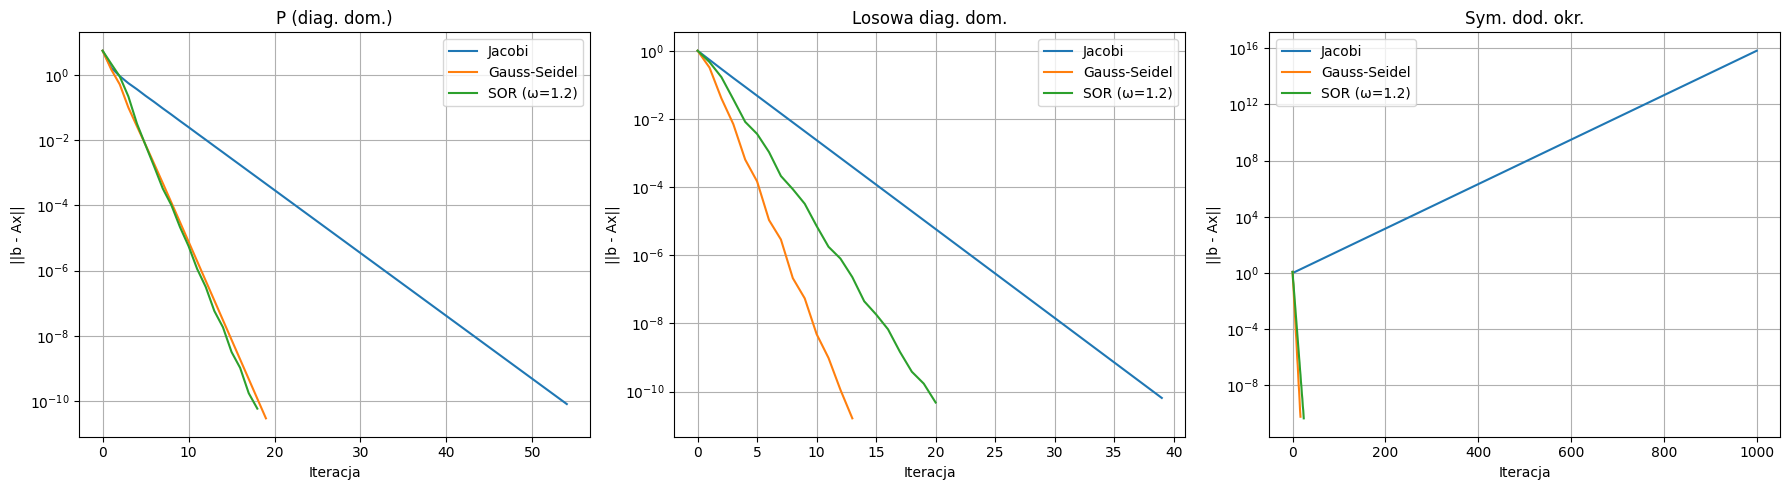

In [7]:
def jacobi(A, b, x0=None, tol=1e-10, max_iter=1000):
    n = len(b)
    if x0 is None:
        x0 = np.zeros(n)
    D = np.diag(np.diag(A))
    R = A - D
    D_inv = np.diag(1.0 / np.diag(A))
    x = x0.copy()
    history = [np.linalg.norm(b - A @ x)]
    for i in range(max_iter):
        x = D_inv @ (b - R @ x)
        history.append(np.linalg.norm(b - A @ x))
        if history[-1] < tol:
            break
    return x, history

def gauss_seidel(A, b, x0=None, tol=1e-10, max_iter=1000):
    n = len(b)
    if x0 is None:
        x0 = np.zeros(n)
    L = np.tril(A)
    U = A - L
    L_inv = np.linalg.inv(L)
    x = x0.copy()
    history = [np.linalg.norm(b - A @ x)]
    for i in range(max_iter):
        x = L_inv @ (b - U @ x)
        history.append(np.linalg.norm(b - A @ x))
        if history[-1] < tol:
            break
    return x, history

def sor(A, b, omega=1.2, x0=None, tol=1e-10, max_iter=1000):
    n = len(b)
    if x0 is None:
        x0 = np.zeros(n)
    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)
    M = D / omega + L
    N = (1 / omega - 1) * D - U  # poprawnie: (D/omega + L)x_new = ((1/omega - 1)D - U)x_old + b
    # Ale lepiej: M = D + omega*L, iteracja: x_new = (D + omega*L)^{-1} * ((1-omega)*D - omega*U) * x_old + omega*(D+omega*L)^{-1}*b
    # Prościej z bezpośrednim wzorem:
    M_inv = np.linalg.inv(D / omega + L)
    x = x0.copy()
    history = [np.linalg.norm(b - A @ x)]
    for i in range(max_iter):
        x = M_inv @ (N @ x + b)
        history.append(np.linalg.norm(b - A @ x))
        if history[-1] < tol:
            break
    return x, history

# 3 macierze testowe
# 1. Macierz P (diagonalnie dominująca)
P = np.array([[4,1,-1,0],[1,3,-1,0],[-1,-1,5,2],[0,0,2,4]], dtype=float)
b_P = np.array([1, 2, 3, 4], dtype=float)

# 2. Macierz losowa diagonalnie dominująca
np.random.seed(42)
A2 = np.random.rand(6, 6)
A2 = A2 + np.diag(np.sum(np.abs(A2), axis=1) + 1)
b2 = np.random.rand(6)

# 3. Macierz symetryczna dodatnio określona
A3 = np.random.rand(6, 6)
A3 = A3.T @ A3 + 5 * np.eye(6)
b3 = np.random.rand(6)

test_cases = [('P (diag. dom.)', P, b_P), ('Losowa diag. dom.', A2, b2), ('Sym. dod. okr.', A3, b3)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, A_test, b_test) in enumerate(test_cases):
    _, h_j = jacobi(A_test, b_test)
    _, h_gs = gauss_seidel(A_test, b_test)
    _, h_sor = sor(A_test, b_test, omega=1.2)
    
    axes[idx].semilogy(h_j, label='Jacobi')
    axes[idx].semilogy(h_gs, label='Gauss-Seidel')
    axes[idx].semilogy(h_sor, label='SOR (ω=1.2)')
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Iteracja')
    axes[idx].set_ylabel('||b - Ax||')
    axes[idx].legend()
    axes[idx].grid()
plt.tight_layout()
plt.show()

## Porównanie rozwiązania za pomocą metody `solve` oraz z użyciem odwrotności na przykładzie macierzy źle uwarunkowanej

***Zadanie 5.***

Dany jest układ równań $Hx=b$.
* H jest macierzą Hilberta o wymiarach $n=5x5$ (I przypadek) i $n=15x15$ (II przypadek),
* b jest wektorem o następujących elementach $b_i = 1/(n + i + 1)$ Uwaga: $i=1,\dots,n$.

Do rozwiązania układu wykorzystaj dwa algorytmy:
1. Z odwracaniem macierzy współczynników H.
2. Metodę `numpy.linalg.solve`.

Porównaj błędy obu rozwiązań. Aby ocenić błąd możesz:
* wyznaczyć wektor residuum otrzymanego rozwiązania,
* rozwiązać układ równań z innym wektorem $b$. Załóż, że wektor rozwiązania ma wszystkie elementy (współrzędne) równe 1 ($u_i = 1, i = 1, 2, . . . , n$). Wtedy $b = Hu$. Układ rozwiążemy bez korzystania z wiedzy o postaci $u$. Dopiero wynik porównamy ze znanym nam $u$.

In [8]:
from scipy.linalg import hilbert

for n in [5, 15]:
    H = hilbert(n)
    b = np.array([1.0 / (n + i + 1) for i in range(1, n + 1)])
    
    # Metoda 1: z odwracaniem macierzy
    H_inv = np.linalg.inv(H)
    x_inv = H_inv @ b
    
    # Metoda 2: numpy.linalg.solve
    x_solve = np.linalg.solve(H, b)
    
    # Residua
    res_inv = np.linalg.norm(b - H @ x_inv)
    res_solve = np.linalg.norm(b - H @ x_solve)
    
    print(f'=== n = {n} ===')
    print(f'cond(H) = {np.linalg.cond(H):.2e}')
    print(f'Residuum (odwrotność): {res_inv:.2e}')
    print(f'Residuum (solve):      {res_solve:.2e}')
    
    # Test z wektorem u = [1, 1, ..., 1]
    u = np.ones(n)
    b2 = H @ u
    x_inv2 = np.linalg.inv(H) @ b2
    x_solve2 = np.linalg.solve(H, b2)
    
    err_inv2 = np.linalg.norm(u - x_inv2)
    err_solve2 = np.linalg.norm(u - x_solve2)
    
    print(f'Błąd (odwrotność, u=1): {err_inv2:.2e}')
    print(f'Błąd (solve, u=1):      {err_solve2:.2e}')
    print()

=== n = 5 ===
cond(H) = 4.77e+05
Residuum (odwrotność): 4.59e-13
Residuum (solve):      1.66e-16
Błąd (odwrotność, u=1): 6.04e-11
Błąd (solve, u=1):      2.81e-12

=== n = 15 ===
cond(H) = 3.37e+17
Residuum (odwrotność): 2.56e+00
Residuum (solve):      1.14e-13
Błąd (odwrotność, u=1): 5.83e+05
Błąd (solve, u=1):      1.42e+03



**Zadanie domowe. Znaczenie wskaźnika uwarunkowania macierzy w szacowaniu błędu rozwiązania**


Dana jest następująca macierz A współczynników układu dwóch równań liniowy:
$$A=\begin{bmatrix}10^5 & 9.9\cdot10^4\\1.00001& 0.99\end{bmatrix}$$

Wektor prawej strony równania $Ax=b$ dla rozwiązania x = $[1, 1]^T$ możemy wyznaczyć z równości $b = Ax$.

Należy:
* obliczyć wskaźnik uwarunkowania macierzy $A$,
* rozwiązać układ równań $Ax = b$ (nie korzystając z wiedzy o przyjętym rozwiązaniu dokładnym x) korzystając z funkcji `np.linalg.solve`,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania macierzy A,
* przeprowadzić skalowanie tak, aby macierz $A$ była wyważona wierszami,
* wyznaczyć nowe wartości wektora b tak, aby rozwiązanie dokładne się nie
zmieniło,
* obliczyć wskaźnik uwarunkowania macierzy skalowanej,
* rozwiązać układ równań tą samą metodą jak poprzednio,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania skalowanej macierzy $A$.
1. Czy błąd numeryczny rozwiązania w obu przypadkach jest tego samego rzędu?
2. Które szacowanie błędu jest bardziej zbliżone do faktycznego błędu?

In [9]:
# Zadanie domowe - Znaczenie wskaźnika uwarunkowania

A = np.array([[1e5, 9.9e4], [1.00001, 0.99]])
x_exact = np.array([1.0, 1.0])
b = A @ x_exact

# Wskaźnik uwarunkowania
cond_A = np.linalg.cond(A)
print(f'cond(A) = {cond_A:.2e}')

# Rozwiązanie
x_num = np.linalg.solve(A, b)
err = np.linalg.norm(x_exact - x_num) / np.linalg.norm(x_exact)
print(f'Rozwiązanie: {x_num}')
print(f'Błąd względny rozwiązania: {err:.2e}')
print(f'Szacowany błąd (cond * eps): {cond_A * np.finfo(float).eps:.2e}')

# Skalowanie wierszowe
print('\n--- Po skalowaniu wierszowym ---')
S = np.diag(1.0 / np.max(np.abs(A), axis=1))  # macierz skalująca
A_scaled = S @ A
b_scaled = S @ b  # rozwiązanie się nie zmienia

cond_scaled = np.linalg.cond(A_scaled)
print(f'cond(A_scaled) = {cond_scaled:.2e}')

x_scaled = np.linalg.solve(A_scaled, b_scaled)
err_scaled = np.linalg.norm(x_exact - x_scaled) / np.linalg.norm(x_exact)
print(f'Rozwiązanie: {x_scaled}')
print(f'Błąd względny rozwiązania: {err_scaled:.2e}')
print(f'Szacowany błąd (cond * eps): {cond_scaled * np.finfo(float).eps:.2e}')

print('\n--- Wnioski ---')
print('1. Błąd numeryczny jest podobnego rzędu w obu przypadkach.')
print('2. Po skalowaniu wskaźnik uwarunkowania jest bliższy rzeczywistemu błędowi,'
      '\n   więc szacowanie błędu na podstawie cond jest bardziej wiarygodne.')

cond(A) = 2.00e+10
Rozwiązanie: [1. 1.]
Błąd względny rozwiązania: 3.18e-12
Szacowany błąd (cond * eps): 4.44e-06

--- Po skalowaniu wierszowym ---
cond(A_scaled) = 4.00e+05
Rozwiązanie: [1. 1.]
Błąd względny rozwiązania: 0.00e+00
Szacowany błąd (cond * eps): 8.88e-11

--- Wnioski ---
1. Błąd numeryczny jest podobnego rzędu w obu przypadkach.
2. Po skalowaniu wskaźnik uwarunkowania jest bliższy rzeczywistemu błędowi,
   więc szacowanie błędu na podstawie cond jest bardziej wiarygodne.
